<a href="https://colab.research.google.com/github/OlhaZahrebelna/Behaviour_bank_project/blob/main/Behaviour_bank__Project_ENG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Main Task
The task is to build a model to predict whether a bank client will subscribe to a term deposit.

### Variable Description


#### **Bank Client Data:**
1. **age** – client’s age (numeric).
2. **job** – type of occupation (categorical: admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown).
3. **marital** – marital status (categorical: divorced, married, single, unknown; note: divorced includes divorced or widowed).
4. **education** – education level (categorical: basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown).
5. **default** – has the client defaulted on credit? (categorical: no, yes, unknown).
6. **housing** – does the client have a housing loan? (categorical: no, yes, unknown).
7. **loan** – does the client have a personal loan? (categorical: no, yes, unknown).

#### **Data Related to the Last Contact in the Current Marketing Campaign:**
8. **contact** – communication type of the last contact (categorical: cellular, telephone).
9. **month** – month of the last contact (categorical: jan, feb, mar, …, nov, dec).
10. **day_of_week** – day of the week of the last contact (categorical: mon, tue, wed, thu, fri).
11. **duration** – duration of the last contact in seconds (numeric).
⚠ Important note: this variable has a strong impact on the target variable (e.g., if duration = 0, then y = no). However, duration is not known before the call is made. Moreover, after the call is completed, the target variable is already known.

#### **Other Attributes:**
12. **campaign** – number of contacts performed during this campaign for this client (numeric, includes the last contact).
13. **pdays** – number of days since the client was last contacted in a previous campaign (numeric; 999 means the client was not previously contacted).
14. **previous** – number of contacts performed before this campaign for this client (numeric).
15. **poutcome** – outcome of the previous marketing campaign (categorical: failure, nonexistent, success).

#### **Social and Economic Context Attributes:**
16. **emp.var.rate** – employment variation rate (quarterly indicator, numeric).
17 **cons.price.idx** – consumer price index (monthly indicator, numeric).
18. **cons.conf.idx** – consumer confidence index (monthly indicator, numeric).
19. **euribor3m** – Euribor 3-month rate (daily indicator, numeric).
20. **nr.employed** – number of employed people (quarterly indicator, numeric).

#### **Target Variable:**
21. **y** – has the client subscribed to a term deposit? (binary: yes, no).


In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
# === Основні бібліотеки ===
import numpy as np
import pandas as pd

# === Візуалізація ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Sklearn preprocessing & pipeline ===
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer

# === Data split ===
from sklearn.model_selection import train_test_split

# === Моделі ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

# === Балансування ===
from imblearn.over_sampling import SMOTE

# === Метрики ===
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score
)

# === Hyperparameter tuning ===
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# === Інтерпретація ===
import shap


import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [64]:
df = pd.read_csv('/content/drive/MyDrive/Mid-Tech project/bank-additional-full.csv', sep=';')
df.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

There are no missing values in the dataset

In [66]:
df.nunique()

,0
age,78
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5


The table shows the number of unique values in each column.

In [67]:
print(df['month'].unique())

['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']


In [68]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


The analysis of descriptive statistics shows that the average age of clients is 40 years, the median is 38 years, and 75% of clients are under 47 years old. This indicates that most bank clients belong to the working-age population.

The duration of the last contact (duration) has a mean of 258 seconds, while the median is 180 seconds, which may indicate a skewed distribution with the presence of long calls (maximum — 4918 seconds).

The number of contacts during the current campaign (campaign) is generally low: the median is 2 contacts, and 75% of clients received no more than 3 calls. However, the maximum value is 56 contacts, which may indicate outliers or aggressive repeated contact attempts.

The pdays variable has a median value of 999, meaning that most clients were not previously contacted in earlier campaigns. This is further supported by the previous variable, where 75% of values are 0, indicating that there were effectively no prior contacts.

Socio-economic indicators (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) show relatively low variability, as they are macroeconomic indicators that change more slowly than individual client characteristics.

In [69]:
df_positive = df[df['y'] == 'yes']
df_negative = df[df['y'] == 'no']

In [70]:
df_positive.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000,4640.000000
mean,40.913147,553.191164,2.051724,792.035560,0.492672,-1.233448,93.354386,-39.789784,2.123135,5095.115991
std,13.837476,401.171871,1.666245,403.407181,0.860344,1.623626,0.676644,6.139668,1.742598,87.572641
min,17.000000,37.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,31.000000,253.000000,1.000000,999.000000,0.000000,-1.800000,92.893000,-46.200000,0.849000,5017.500000
50%,37.000000,449.000000,2.000000,999.000000,0.000000,-1.800000,93.200000,-40.400000,1.266000,5099.100000
75%,50.000000,741.250000,2.000000,999.000000,1.000000,-0.100000,93.918000,-36.100000,4.406000,5191.000000
max,98.000000,4199.000000,23.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [71]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.887346
yes,0.112654


There is a significant class imbalance (the number of yes instances is much smaller than no).

In [72]:
df['y_binary'] = df['y'].map({'no': 0, 'yes': 1})

In [73]:
df.corr(numeric_only=True)['y_binary'].sort_values(ascending=False)

,y_binary
y_binary,1.000000
duration,0.405274
previous,0.230181
cons.conf.idx,0.054878
age,0.030399
campaign,-0.066357
cons.price.idx,-0.136211
emp.var.rate,-0.298334
euribor3m,-0.307771
pdays,-0.324914


The table shows the correlation between numerical features and the target variable (y_binary), sorted in descending order.

In [74]:
df.drop(columns=['y_binary'], inplace=True)

Correlation analysis showed that the variable duration has the strongest positive relationship with term deposit subscription, meaning that the longer the conversation with a client, the higher the probability of a successful outcome. However, this variable cannot be used in the final model because its value is only known after the call is completed.

A positive relationship is also observed for the **previous** variable, which may indicate a higher likelihood of success among clients who have been contacted before.

Macroeconomic indicators **(euribor3m, emp.var.rate, nr.employed, pdays)** show a negative correlation with the target variable.

In [75]:
categorical = df.dtypes[df.dtypes == 'object'].index

for col in categorical:
    print(f"\n{col}")
    print(df[col].value_counts())


job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
contact
ce

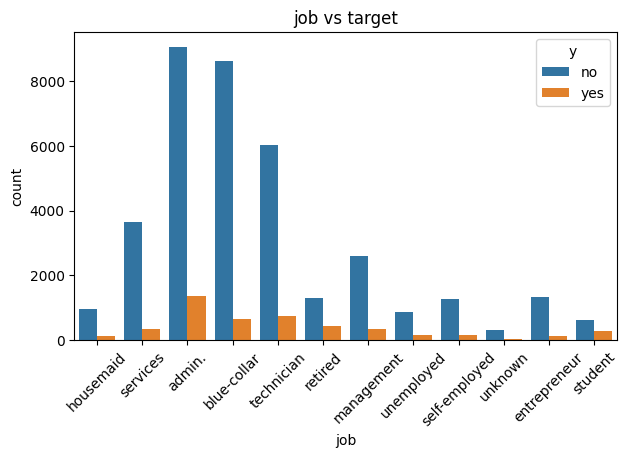

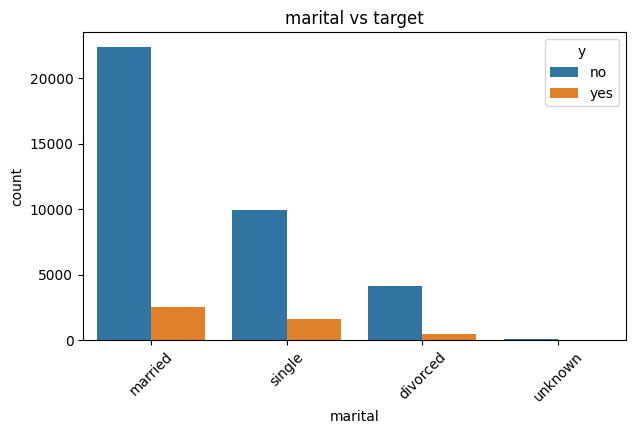

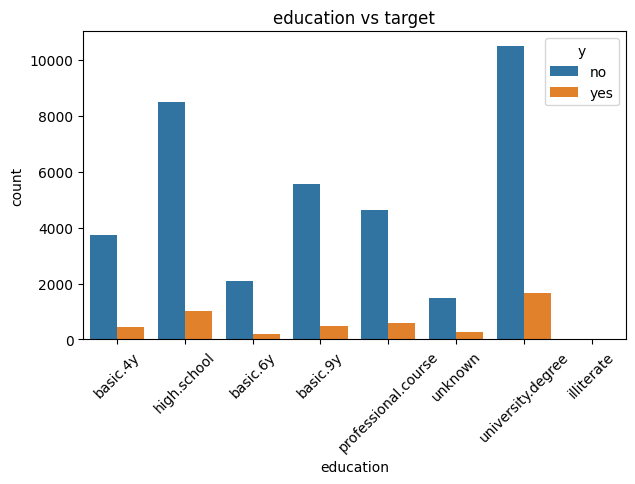

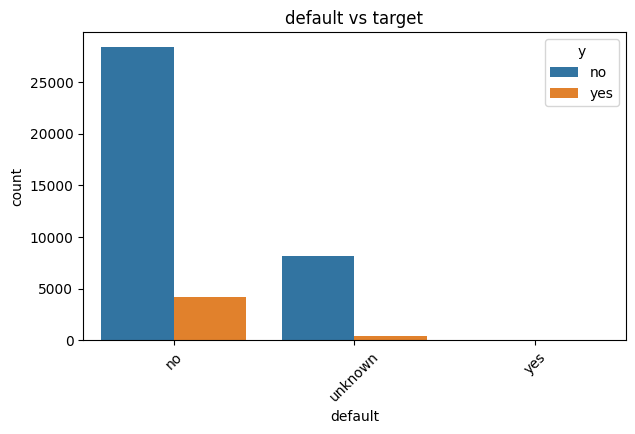

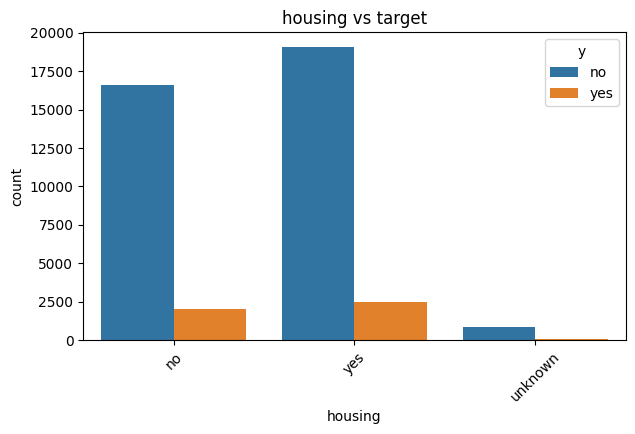

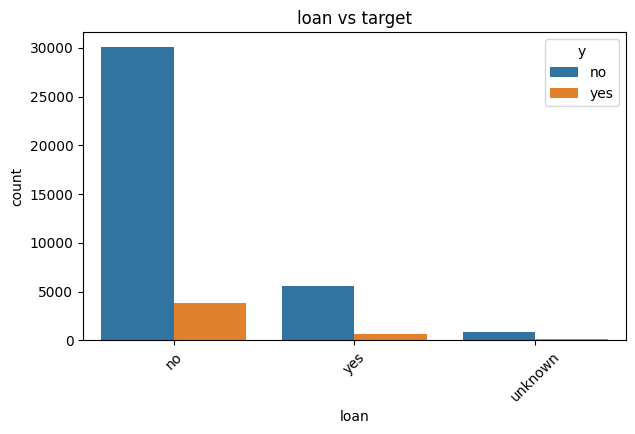

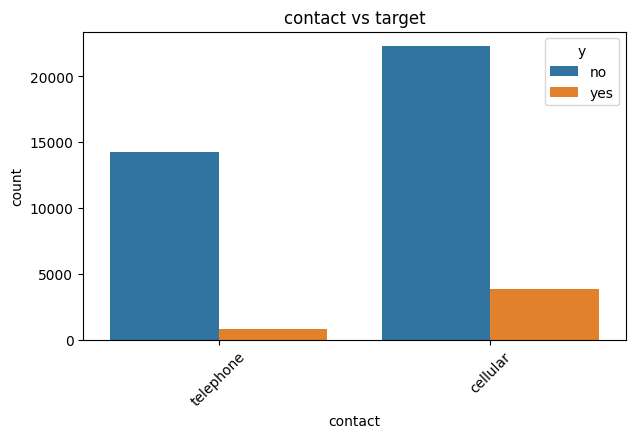

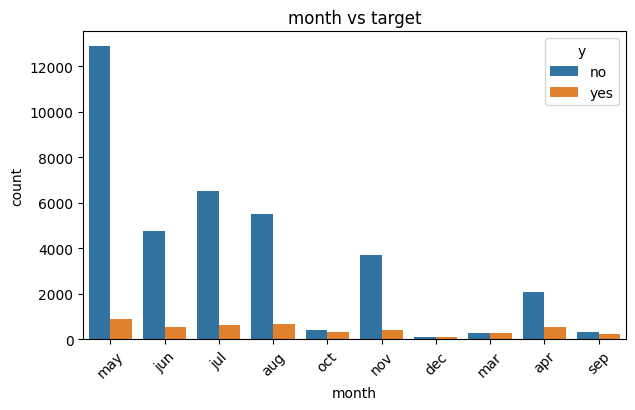

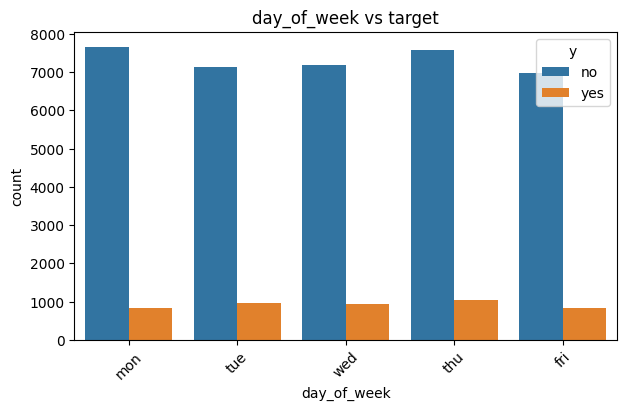

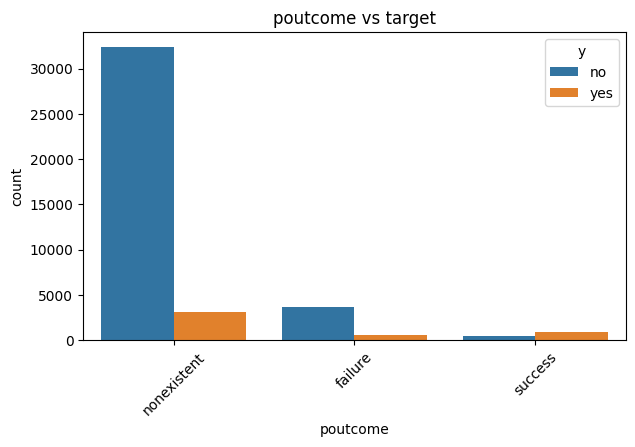

In [76]:
for col in categorical:
    if col != 'y':
        plt.figure(figsize=(7,4))
        sns.countplot(data=df, x=col, hue='y')
        plt.title(f'{col} vs target')
        plt.xticks(rotation=45)
        plt.show()

The analysis of bar plots shows that the number of clients who did not subscribe to a deposit (`no`) significantly exceeds those who did (`yes`). This indicates a substantial class imbalance in the target variable, which must be taken into account when building machine learning models.

### Job
The largest share of clients belongs to the categories `admin`, `technician`, and `blue-collar`.  
At the same time, a relatively higher proportion of positive responses (`yes`) is observed among `retired` clients and `students`, which may indicate a greater interest in saving money within these groups.

### Marital Status (marital)
The majority of clients fall into the `married` category, which is expected for an adult population.  
However, there are no significant differences in the ratio of `yes` and `no` across marital categories, suggesting that marital status is not a strong factor influencing the decision to subscribe to a deposit.

### Education
Most clients have `high school` or `university degree` education.  
In all education categories, the `no` response dominates, but clients with higher education (`university degree`) show a slightly higher number of positive responses, which may be related to higher income or better financial literacy.

### Default
Most clients do not have credit defaults (`no`), while the `yes` category is almost absent.  
Due to the very small number of such cases, it is difficult to draw meaningful conclusions about the impact of this variable.

### Housing Loan (housing)
The distribution between `yes` and `no` is relatively balanced, with no clear difference in the proportion of clients subscribing to a deposit.  
This suggests that having a housing loan is not a strong factor in the decision-making process.

### Personal Loan (loan)
Most clients do not have a personal loan, and among them, there are also more cases of deposit subscription.  
However, this pattern largely reflects the overall class imbalance in the target variable.

### Contact Type (contact)
Clients contacted via `cellular` communication were significantly more likely to subscribe to a deposit compared to those contacted via `telephone`.  
This may indicate higher effectiveness of the mobile communication channel.

### Month
The number of contacts varies significantly across months.  
The highest number of contacts occurred in May, but the proportion of positive responses is relatively low.  
Some other months show a relatively higher share of `yes`, which may suggest seasonality in marketing campaign outcomes.

### Day of Week (day_of_week)
The distribution of contacts across weekdays is fairly uniform, with no significant differences in the proportion of clients subscribing to a deposit.

### Previous Campaign Outcome (poutcome)
This variable shows the most noticeable relationship with the target variable.  
Clients who had a successful outcome in a previous marketing campaign (`success`) are significantly more likely to subscribe to a deposit.  
This suggests that the history of previous interactions is an important factor in predicting client behavior.

## Hypotheses

### Hypothesis 1:
Clients with the `retired` or `student` occupation have a higher probability of subscribing to a deposit compared to other occupational groups.  
**Justification:**  
The plots show that these categories have a higher relative share of `yes` responses. This may be because retirees have accumulated savings, while students may use deposits as a way to save money.

### Hypothesis 2:
Clients with higher education (`university degree`) are more likely to subscribe to a deposit.  
**Justification:**  
Individuals with higher education may have: higher income, better financial literacy, and a greater tendency toward investment and saving.

### Hypothesis 3:
Contact via mobile phone (`cellular`) is more effective for deposit subscription than contact via landline (`telephone`).  
**Justification:**  
The bar plot shows that the share of positive responses is significantly higher among clients contacted via mobile phone.

### Hypothesis 4:
Clients who had a successful outcome in a previous marketing campaign (`success`) are much more likely to subscribe to a deposit.  
**Justification:**  
A positive prior experience with the bank may increase trust in its financial products.

### Hypothesis 5:
Clients who were previously contacted in earlier campaigns are more likely to subscribe to a deposit.  
**Justification:**  
There is a positive correlation between `previous` and the target variable (≈ 0.23), which may indicate a higher level of trust among clients who have already interacted with the bank.

### Hypothesis 6:
The shorter the time since the last contact with a client, the higher the probability of successful subscription.  
**Justification:**  
A negative correlation (≈ -0.32) is observed, suggesting that clients contacted more recently are more likely to subscribe.

### Hypothesis 7:
A deterioration in economic conditions may increase the likelihood of deposit subscription.  
**Justification:**  
There is a negative correlation between the target variable and macroeconomic indicators such as `euribor3m`, `emp.var.rate`, and `nr.employed`.  
This may indicate that during periods of economic instability, clients are more likely to choose saving as a safer financial strategy.

### Hypothesis 8:
The probability of deposit subscription depends on the month of contact, which may indicate seasonality in the marketing campaign.  
**Justification:**  
The plot shows that the number of positive responses varies depending on the month.

## Model Evaluation Metric — F1-Score

Since the target variable is significantly imbalanced (`yes` is much less frequent than `no`), relying solely on accuracy may lead to misleading results. Therefore, it is more appropriate to use evaluation metrics that account for the balance between classification errors, such as:

- **Precision** — out of all predicted `yes` cases, how many were correct  
- **Recall** — how many of the actual `yes` cases the model was able to identify  
- **F1-score** — a balance between precision and recall  

In addition, **ROC-AUC** can be used for model comparison, as it measures the model’s ability to distinguish between positive and negative classes.

### Logistic Regression (Baseline)

**How does it work?**

- First, the model computes a linear combination of the features  
- Then, it applies the sigmoid function  
- As a result, it outputs a value between 0 and 1  
- The model then makes a decision for each value in the test set (i.e., performs classification)

In this case, a standard threshold of **0.5** is used:  
- if ≥ 0.5 → class 1 (`yes`)  
- if < 0.5 → class 0 (`no`)  



In [77]:
df_model = df.drop(columns=["duration"]).copy()

X = df_model.drop(columns=["y"])
y = df_model["y"].map({"no": 0, "yes": 1})


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [78]:
def feature_engineering(X):
    X = X.copy()


    cat_cols = X.select_dtypes(include="object").columns
    for col in cat_cols:
        X[col] = X[col].replace("unknown", np.nan)

    if "previous" in X.columns:
        X["was_contacted_before"] = (X["previous"] > 0).astype(int)

    if "pdays" in X.columns:
        X["previous_campaign_contact"] = (X["pdays"] != 999).astype(int)
        X["pdays_clean"] = X["pdays"].replace(999, np.nan)
        X = X.drop(columns=["pdays"])

    if {"housing", "loan"}.issubset(X.columns):
        X["has_any_loan"] = (
            ((X["housing"] == "yes") | (X["loan"] == "yes")).astype(int)
        )

    if "campaign" in X.columns:
        X["campaign_group"] = pd.cut(
            X["campaign"],
            bins=[-np.inf, 1, 3, 6, np.inf],
            labels=["1", "2-3", "4-6", "7+"]
        )

    if "age" in X.columns:
        X["age_group"] = pd.cut(
            X["age"],
            bins=[0, 25, 40, 60, 100],
            labels=["18-25", "26-40", "41-60", "60+"]
        )

    return X


feature_transformer = FunctionTransformer(feature_engineering)

In [79]:
X_train_fe = feature_engineering(X_train)

cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

pipeline = ImbPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineering)),
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function feature_engineering at 0x7a11a295c4a0>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'campaign',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.e...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome', 'campaign_group',
                                                   'age_group'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

In [80]:
y_pred_train = pipeline.predict(X_train)
y_proba_train = pipeline.predict_proba(X_train)[:,1]
y_pred_val = pipeline.predict(X_val)
y_proba_val = pipeline.predict_proba(X_val)[:, 1]
y_pred_test = pipeline.predict(X_test)
y_proba_test = pipeline.predict_proba(X_test)[:, 1]

In [81]:
print(f"Train LogisticRegression")
print(classification_report(y_train, y_pred_train))
print("Val LogisticRegression")
print(classification_report(y_val, y_pred_val))
print("Test LogisticRegression")
print(classification_report(y_test, y_pred_test))
print("Train ROC-AUC LogisticRegression:", roc_auc_score(y_train, y_proba_train))
print("Val ROC-AUC LogisticRegression:", roc_auc_score(y_val, y_proba_val))
print("Test ROC-AUC LogisticRegression:", roc_auc_score(y_test, y_proba_test))

Train LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.84      0.89     21928
           1       0.34      0.63      0.44      2784

    accuracy                           0.82     24712
   macro avg       0.64      0.74      0.67     24712
weighted avg       0.88      0.82      0.84     24712

Val LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

Test LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      7310
           1       0.35      0.65      0.45       928

    accuracy                           0.82      8238
   macro avg       0.65      0.75      0.67      8238
we

In [82]:
pipeline.named_steps["model"].get_params()

{'C': 1.0,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 2000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

The logistic regression model demonstrates consistent performance across the train, validation, and test sets, indicating no signs of overfitting and a well-constructed pipeline.

The main issue is the low predictive quality for the positive class (clients who subscribe to a deposit): with a recall of 0.65, the model has low precision (0.35), leading to a high number of false positive predictions.

This means the model tends to overestimate the probability of client agreement, which may be inefficient from a business cost perspective.

Therefore, further model improvement should focus on optimizing the F1-score for the "yes" class and achieving a better balance between precision and recall.

### Logistic Regression with Adjusted Threshold

In [83]:
thresholds = np.arange(0.1, 0.9, 0.01)
scores = []

for t in thresholds:
    y_pred_temp = (y_proba_val >= t).astype(int)
    scores.append(f1_score(y_val, y_pred_temp))

best_t = thresholds[np.argmax(scores)]

print("Best threshold:", best_t)

Best threshold: 0.6599999999999997


In [84]:
y_proba_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_t).astype(int)

print(f"Train LogisticRegression")
print(classification_report(y_train, y_pred_train))
print("Test LogisticRegression")
print(classification_report(y_val, y_pred_val))
print("Test LogisticRegression")
print(classification_report(y_test, y_pred_test))
print("Train ROC-AUC LogisticRegression:", roc_auc_score(y_train, y_proba_train))
print("Val ROC-AUC LogisticRegression:", roc_auc_score(y_val, y_proba_val))
print("Test ROC-AUC LogisticRegression:", roc_auc_score(y_test, y_proba_test))

Train LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.84      0.89     21928
           1       0.34      0.63      0.44      2784

    accuracy                           0.82     24712
   macro avg       0.64      0.74      0.67     24712
weighted avg       0.88      0.82      0.84     24712

Test LogisticRegression
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

Test LogisticRegression
              precision    recall  f1-score   support

           0       0.94      0.91      0.92      7310
           1       0.44      0.56      0.49       928

    accuracy                           0.87      8238
   macro avg       0.69      0.74      0.71      8238
w

In [85]:
pipeline.named_steps["model"].get_params()

{'C': 1.0,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 2000,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

The logistic regression model shows stable performance across all datasets with no signs of overfitting. After optimizing the classification threshold, the prediction quality for the positive class improved: precision increased from ~0.35 to ~0.44, and the F1-score rose from ~0.45 to ~0.49.

This indicates a reduction in false positive predictions and improved reliability of the model from a business perspective. At the same time, there was a slight decrease in recall, which is an expected trade-off.

Thus, threshold tuning allowed for a better balance between precision and recall and increased the practical value of the model.

###RandomForestClassifier

**How does it work?**

- Multiple random subsamples are created from the training data (bootstrap sampling)  
- A separate decision tree is built for each subsample  
- Each tree is trained independently and uses a random subset of features  
- For each instance in the test set, every tree makes a prediction (i.e., predicts `yes` or `no`)  
- The final result is determined by majority voting or by the proportion of votes for the positive class  

In [86]:
pipeline_Random_forest = ImbPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineering)),
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(class_weight="balanced"))
])

In [87]:
pipeline_Random_forest.fit(X_train, y_train)

y_pred_forest_train = pipeline_Random_forest.predict(X_train)
y_proba_forest_train = pipeline_Random_forest.predict_proba(X_train)[:, 1]
y_pred_forest_val = pipeline_Random_forest.predict(X_val)
y_proba_forest_val = pipeline_Random_forest.predict_proba(X_val)[:, 1]
y_pred_forest_test = pipeline_Random_forest.predict(X_test)
y_proba_forest_test = pipeline_Random_forest.predict_proba(X_test)[:, 1]

print("Train RandomForestClassifier", classification_report(y_train, y_pred_forest_train))
print("Val RandomForestClassifier", classification_report(y_val, y_pred_forest_val))
print("Test RandomForestClassifier", classification_report(y_test, y_pred_forest_test))
print("Train ROC-AUC RandomForestClassifier", roc_auc_score(y_train, y_proba_forest_train))
print("Val ROC-AUC RandomForestClassifier", roc_auc_score(y_val, y_proba_forest_val))
print("Test ROC-AUC RandomForestClassifier", roc_auc_score(y_test, y_proba_forest_test))

Train RandomForestClassifier               precision    recall  f1-score   support

           0       1.00      1.00      1.00     21928
           1       0.99      0.98      0.98      2784

    accuracy                           1.00     24712
   macro avg       0.99      0.99      0.99     24712
weighted avg       1.00      1.00      1.00     24712

Val RandomForestClassifier               precision    recall  f1-score   support

           0       0.92      0.96      0.94      7310
           1       0.52      0.36      0.42       928

    accuracy                           0.89      8238
   macro avg       0.72      0.66      0.68      8238
weighted avg       0.88      0.89      0.88      8238

Test RandomForestClassifier               precision    recall  f1-score   support

           0       0.92      0.96      0.94      7310
           1       0.50      0.34      0.41       928

    accuracy                           0.89      8238
   macro avg       0.71      0.65      0.67 

In [88]:
pipeline_Random_forest.named_steps["model"].get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

The Random Forest model demonstrates significant overfitting: near-perfect performance on the training set does not generalize to the validation and test sets. Despite an acceptable accuracy level (0.89), the model shows low recall for the positive class (0.35), meaning that a large number of potential clients are missed.

Compared to Logistic Regression, Random Forest exhibits a poorer balance between precision and recall, as well as a lower F1-score for the "yes" class. Therefore, in its current form, the model is less effective for this task.

### k-Nearest Neighbors (k-NN) or “Tell me who your neighbors are, and I will tell you who you are”

**How does it work?**

- For each instance in the test set, the model finds the *k* nearest neighbors in the training data  
- Closeness is determined using a distance metric (e.g., Euclidean distance)  
- Among the selected neighbors, the model checks which class they belong to  
- The final prediction for the instance is the class that appears most frequently among the *k* neighbors  

In [89]:
pipeline_knn = ImbPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineering)),
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", KNeighborsClassifier())
])

pipeline_knn.fit(X_train, y_train)
y_pred_knn_train = pipeline_knn.predict(X_train)
y_proba_knn_train = pipeline_knn.predict_proba(X_train)[:, 1]
y_pred_knn_val = pipeline_knn.predict(X_val)
y_proba_knn_val = pipeline_knn.predict_proba(X_val)[:, 1]
y_pred_knn_test = pipeline_knn.predict(X_test)
y_proba_knn_test = pipeline_knn.predict_proba(X_test)[:, 1]

print("Train KNN", classification_report(y_train, y_pred_knn_train))
print("Val KNN", classification_report(y_val, y_pred_knn_val))
print("Test KNN", classification_report(y_test, y_pred_knn_test))
print("Train ROC-AUC KNN:", roc_auc_score(y_train, y_proba_knn_train))
print("Val ROC-AUC KNN:", roc_auc_score(y_val, y_proba_knn_val))
print("Test ROC-AUC KNN:", roc_auc_score(y_test, y_proba_knn_test))

Train KNN               precision    recall  f1-score   support

           0       1.00      0.79      0.88     21928
           1       0.37      0.98      0.54      2784

    accuracy                           0.81     24712
   macro avg       0.69      0.89      0.71     24712
weighted avg       0.93      0.81      0.84     24712

Val KNN               precision    recall  f1-score   support

           0       0.94      0.72      0.82      7310
           1       0.23      0.66      0.34       928

    accuracy                           0.71      8238
   macro avg       0.59      0.69      0.58      8238
weighted avg       0.86      0.71      0.76      8238

Test KNN               precision    recall  f1-score   support

           0       0.94      0.73      0.82      7310
           1       0.23      0.64      0.34       928

    accuracy                           0.72      8238
   macro avg       0.58      0.68      0.58      8238
weighted avg       0.86      0.72      0.77    

In [90]:
pipeline_knn.named_steps["model"].get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

The KNN model shows signs of overfitting: performance on the training set is significantly higher than on the validation and test sets. In particular, ROC-AUC decreases from ~0.98 on the training set to ~0.72 on the validation/test sets, indicating limited generalization ability.

### KNN without Synthetic Data Generation

In [91]:
pipeline_knn = ImbPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineering)),
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

pipeline_knn.fit(X_train, y_train)
y_pred_knn_train = pipeline_knn.predict(X_train)
y_proba_knn_train = pipeline_knn.predict_proba(X_train)[:, 1]
y_pred_knn_val = pipeline_knn.predict(X_val)
y_proba_knn_val = pipeline_knn.predict_proba(X_val)[:, 1]
y_pred_knn_test = pipeline_knn.predict(X_test)
y_proba_knn_test = pipeline_knn.predict_proba(X_test)[:, 1]

print("Train KNN", classification_report(y_train, y_pred_knn_train))
print("Val KNN", classification_report(y_val, y_pred_knn_val))
print("Test KNN", classification_report(y_test, y_pred_knn_test))
print("Train ROC-AUC KNN:", roc_auc_score(y_train, y_proba_knn_train))
print("Val ROC-AUC KNN:", roc_auc_score(y_val, y_proba_knn_val))
print("Test ROC-AUC KNN:", roc_auc_score(y_test, y_proba_knn_test))

Train KNN               precision    recall  f1-score   support

           0       0.92      0.98      0.95     21928
           1       0.73      0.35      0.47      2784

    accuracy                           0.91     24712
   macro avg       0.83      0.67      0.71     24712
weighted avg       0.90      0.91      0.90     24712

Val KNN               precision    recall  f1-score   support

           0       0.91      0.98      0.94      7310
           1       0.57      0.26      0.36       928

    accuracy                           0.89      8238
   macro avg       0.74      0.62      0.65      8238
weighted avg       0.87      0.89      0.88      8238

Test KNN               precision    recall  f1-score   support

           0       0.91      0.97      0.94      7310
           1       0.56      0.26      0.36       928

    accuracy                           0.89      8238
   macro avg       0.73      0.62      0.65      8238
weighted avg       0.87      0.89      0.88    

In [92]:
pipeline_knn.named_steps["model"].get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

After removing the use of SMOTE, the KNN model shows a shift in the balance between precision and recall. In particular, precision for the "yes" class increased significantly (from ~0.23 to ~0.56), indicating a reduction in false positive predictions. At the same time, recall dropped substantially (to ~0.26), meaning the model began to miss most positive cases.

Thus, SMOTE did not degrade the model but changed its behavior: with SMOTE, the model was better at identifying the positive class but made more errors, whereas without SMOTE it became more precise but less sensitive to positive examples.

## Boosting

### XGBoost


**How does it work?**

XGBoost is based on decision trees but uses a gradient boosting approach, where each tree is trained on the errors of the previous ones by leveraging gradients of the loss function.

XGBoost = decision trees + gradient optimization + regularization

In [93]:
num_cols_xgb = X_train_fe.select_dtypes(include=np.number).columns.tolist()
cat_cols_xgb = X_train_fe.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_pipeline_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_pipeline_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor_xgb = ColumnTransformer([
    ("num", numeric_pipeline_xgb, num_cols_xgb),
    ("cat", categorical_pipeline_xgb, cat_cols_xgb)
])

pipeline_xgb = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor_xgb),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

pipeline_xgb.fit(X_train, y_train)
y_pred_xgb_train = pipeline_xgb.predict(X_train)
y_proba_xgb_train = pipeline_xgb.predict_proba(X_train)[:, 1]
y_pred_xgb_val = pipeline_xgb.predict(X_val)
y_proba_xgb_val = pipeline_xgb.predict_proba(X_val)[:, 1]
y_pred_xgb_test = pipeline_xgb.predict(X_test)
y_proba_xgb_test = pipeline_xgb.predict_proba(X_test)[:, 1]

print("Train XGB", classification_report(y_train, y_pred_xgb_train))
print("Val XGB", classification_report(y_val, y_pred_xgb_val))
print("Test XGB", classification_report(y_test, y_pred_xgb_test))
print("Train ROC-AUC XGB:", roc_auc_score(y_train, y_proba_xgb_train))
print("Val ROC-AUC:", roc_auc_score(y_val, y_proba_xgb_val))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_test))

Train XGB               precision    recall  f1-score   support

           0       0.93      0.98      0.95     21928
           1       0.69      0.38      0.49      2784

    accuracy                           0.91     24712
   macro avg       0.81      0.68      0.72     24712
weighted avg       0.90      0.91      0.90     24712

Val XGB               precision    recall  f1-score   support

           0       0.92      0.97      0.94      7310
           1       0.58      0.33      0.42       928

    accuracy                           0.90      8238
   macro avg       0.75      0.65      0.68      8238
weighted avg       0.88      0.90      0.88      8238

Test XGB               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7310
           1       0.61      0.31      0.41       928

    accuracy                           0.90      8238
   macro avg       0.76      0.64      0.68      8238
weighted avg       0.88      0.90      0.89    

In [94]:
pipeline_xgb.named_steps["model"].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 300,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

The XGBoost model demonstrates stable performance across the training, validation, and test sets (ROC-AUC 0.80), indicating no significant overfitting.

Compared to previous models, XGBoost improves precision for the positive class (0.61), meaning a reduction in false positive predictions. However, recall remains relatively low (0.31), indicating that the model still misses a substantial portion of clients who would subscribe to a deposit.

Thus, boosting provides more accurate but more conservative predictions: the model makes fewer mistakes but identifies fewer positive cases.

In [95]:
pipeline_xgb_main = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor_xgb),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    ))
])

pipeline_xgb_main.fit(X_train, y_train)
y_pred_xgb_train_main = pipeline_xgb_main.predict(X_train)
y_proba_xgb_train_main = pipeline_xgb_main.predict_proba(X_train)[:, 1]
y_pred_xgb_val_main = pipeline_xgb_main.predict(X_val)
y_proba_xgb_val_main = pipeline_xgb_main.predict_proba(X_val)[:, 1]
y_pred_xgb_test_main = pipeline_xgb_main.predict(X_test)
y_proba_xgb_test_main = pipeline_xgb_main.predict_proba(X_test)[:, 1]

print("Train XGB with scale_pos_weight and without SMOTE", classification_report(y_train, y_pred_xgb_train_main))
print("Val XGB with scale_pos_weight and without SMOTE", classification_report(y_val, y_pred_xgb_val_main))
print("Test XGB with scale_pos_weight and without SMOTE",classification_report(y_test, y_pred_xgb_test_main))
print("Train ROC-AUC XGB with scale_pos_weight and without SMOTE:", roc_auc_score(y_train, y_proba_xgb_train_main))
print("Val ROC-AUC:", roc_auc_score(y_val, y_proba_xgb_val_main))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_test_main))

Train XGB with scale_pos_weight and without SMOTE               precision    recall  f1-score   support

           0       0.96      0.88      0.92     21928
           1       0.42      0.70      0.53      2784

    accuracy                           0.86     24712
   macro avg       0.69      0.79      0.72     24712
weighted avg       0.90      0.86      0.87     24712

Val XGB with scale_pos_weight and without SMOTE               precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.40      0.64      0.49       928

    accuracy                           0.85      8238
   macro avg       0.68      0.76      0.70      8238
weighted avg       0.89      0.85      0.87      8238

Test XGB with scale_pos_weight and without SMOTE               precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.62      0.48       928

    accuracy                       

In [96]:
pipeline_xgb_main.named_steps["model"].get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 300,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': np.float64(7.876436781609195),
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

After removing SMOTE and using `scale_pos_weight`, a better balance between precision and recall was achieved. The model demonstrates higher prediction accuracy compared to the SMOTE-based approach while maintaining a sufficiently high level of recall.

###LGBOOST + Hyperopt

**How does it work?**

- The model builds decision trees sequentially (boosting)  
- The first tree makes a baseline prediction  
- Each subsequent tree is trained on the errors of the previous ones  
- Each new tree improves the overall result  

#### At the same time, the model focuses more on the instances where previous models made mistakes and attempts to reduce these errors in subsequent steps.

In [97]:
X_val_lgb = feature_engineering(X_val)
X_test_lgb = feature_engineering(X_test)
X_train_lgb = feature_engineering(X_train)

In [98]:
cat_cols = X_train_fe.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    X_val_lgb[col] = X_val_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")
    X_train_lgb[col] = X_train_lgb[col].astype("category")

In [99]:
def objective(params):
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"] = int(params["max_depth"])
    params["num_leaves"] = int(params["num_leaves"])
    params["min_child_samples"] = int(params["min_child_samples"])

    clf = lgb.LGBMClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        num_leaves=params["num_leaves"],
        min_child_samples=params["min_child_samples"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        reg_alpha=params["reg_alpha"],
        reg_lambda=params["reg_lambda"],
        min_split_gain=params["min_split_gain"],
        objective="binary",
        random_state=42,
        class_weight="balanced",
        verbose=-1
    )

    clf.fit(
        X_train_lgb,
        y_train,
        eval_set=[(X_val_lgb, y_val)],
        eval_metric="auc",
        categorical_feature=cat_cols
    )

    val_proba = clf.predict_proba(X_val_lgb)[:, 1]
    auc = roc_auc_score(y_val, val_proba)

    return {"loss": -auc, "status": STATUS_OK}

In [100]:
space = {
    "n_estimators": hp.quniform("n_estimators", 100, 500, 25),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.15),
    "max_depth": hp.quniform("max_depth", 3, 10, 1),
    "num_leaves": hp.quniform("num_leaves", 20, 120, 1),
    "min_child_samples": hp.quniform("min_child_samples", 10, 50, 1),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
    "reg_alpha": hp.uniform("reg_alpha", 0.0, 2.0),
    "reg_lambda": hp.uniform("reg_lambda", 0.0, 2.0),
    "min_split_gain": hp.uniform("min_split_gain", 0.0, 0.2)
}

In [101]:
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=25,
    trials=trials,
    rstate=np.random.default_rng(42)
)

best["n_estimators"] = int(best["n_estimators"])
best["max_depth"] = int(best["max_depth"])
best["num_leaves"] = int(best["num_leaves"])
best["min_child_samples"] = int(best["min_child_samples"])

print("Best params:", best)

100%|██████████| 25/25 [00:42<00:00,  1.69s/trial, best loss: -0.812725467592811]
Best params: {'colsample_bytree': np.float64(0.7208716005397193), 'learning_rate': np.float64(0.013197997857263208), 'max_depth': 6, 'min_child_samples': 15, 'min_split_gain': np.float64(0.00019066638592776797), 'n_estimators': 275, 'num_leaves': 30, 'reg_alpha': np.float64(1.4528944916324902), 'reg_lambda': np.float64(0.6859642198840514), 'subsample': np.float64(0.8432450507622776)}


In [102]:
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best["n_estimators"],
    learning_rate=best["learning_rate"],
    max_depth=best["max_depth"],
    num_leaves=best["num_leaves"],
    min_child_samples=best["min_child_samples"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample_bytree"],
    reg_alpha=best["reg_alpha"],
    reg_lambda=best["reg_lambda"],
    min_split_gain=best["min_split_gain"],
    objective="binary",
    random_state=42,
    class_weight="balanced",
    verbose=-1
)

final_lgb_clf.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_val_lgb, y_val)],
    eval_metric="auc",
    categorical_feature=cat_cols
)

train_pred_lgb = final_lgb_clf.predict(X_train_lgb)
train_proba_lgb = final_lgb_clf.predict_proba(X_train_lgb)[:, 1]
val_pred_lgb = final_lgb_clf.predict(X_val_lgb)
val_proba_lgb = final_lgb_clf.predict_proba(X_val_lgb)[:, 1]
test_pred_lgb = final_lgb_clf.predict(X_test_lgb)
test_proba_lgb = final_lgb_clf.predict_proba(X_test_lgb)[:, 1]

train_auc = roc_auc_score(y_train, train_proba_lgb)
val_auc = roc_auc_score(y_val, val_proba_lgb)
tpe_test_auc = roc_auc_score(y_test, test_proba_lgb)

print("Traine Lgb with HP", classification_report(y_train, train_pred_lgb))
print("Val Lgb with HP", classification_report(y_val, val_pred_lgb))
print("Test Lgb with HP", classification_report(y_test, test_pred_lgb))
print(f"Train AUROC with HP: {train_auc:.4f}")
print(f"Validation AUROC with HP: {val_auc:.4f}")
print(f"Test AUROC with HP: {tpe_test_auc:.4f}")

Traine Lgb with HP               precision    recall  f1-score   support

           0       0.95      0.88      0.91     21928
           1       0.40      0.64      0.49      2784

    accuracy                           0.85     24712
   macro avg       0.67      0.76      0.70     24712
weighted avg       0.89      0.85      0.86     24712

Val Lgb with HP               precision    recall  f1-score   support

           0       0.95      0.88      0.92      7310
           1       0.42      0.66      0.51       928

    accuracy                           0.86      8238
   macro avg       0.68      0.77      0.71      8238
weighted avg       0.89      0.86      0.87      8238

Test Lgb with HP               precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.40      0.64      0.50       928

    accuracy                           0.85      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.8

In [103]:
print(final_lgb_clf)

LGBMClassifier(class_weight='balanced',
               colsample_bytree=np.float64(0.7208716005397193),
               learning_rate=np.float64(0.013197997857263208), max_depth=6,
               min_child_samples=15,
               min_split_gain=np.float64(0.00019066638592776797),
               n_estimators=275, num_leaves=30, objective='binary',
               random_state=42, reg_alpha=np.float64(1.4528944916324902),
               reg_lambda=np.float64(0.6859642198840514),
               subsample=np.float64(0.8432450507622776), verbose=-1)


The LightGBM model with tuned hyperparameters demonstrates stable performance across the training, validation, and test sets (AUROC 0.81–0.83), indicating no overfitting and good generalization ability.

For the positive class, the model achieves a balanced trade-off between precision (0.40) and recall (0.64), resulting in the best F1-score (0.50) among all considered models.

Thus, LightGBM is the most effective model for this task, as it provides an optimal balance between prediction accuracy and the ability to identify clients who are likely to subscribe to a deposit.

###LGBOOST + RandomizedSearchCV
Method for Hyperparameter Optimization

In [104]:
param_dist = {
    "num_leaves": [20, 25, 30, 35, 40],
    "learning_rate": [0.005, 0.01, 0.013, 0.02],
    "max_depth": [4, 5, 6, 7, 8],
    "min_child_samples": [10, 15, 20, 25],
    "n_estimators": [200, 250, 275, 300, 350],
    "subsample": [0.75, 0.8, 0.84, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.72, 0.8],
    "reg_alpha": [0.5, 1.0, 1.45, 2.0],
    "reg_lambda": [0.3, 0.5, 0.68, 1.0],
    "min_split_gain": [0.0, 0.0001, 0.001]
}

In [105]:
search = RandomizedSearchCV(estimator=final_lgb_clf, param_distributions=param_dist, n_iter=10, cv=5, scoring='f1', random_state=42, verbose=1, n_jobs=-1)

In [106]:
search.fit(X_train_lgb, y_train, categorical_feature=cat_cols)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(class_weight='balanced',
                                            colsample_bytree=np.float64(0.7208716005397193),
                                            learning_rate=np.float64(0.013197997857263208),
                                            max_depth=6, min_child_samples=15,
                                            min_split_gain=np.float64(0.00019066638592776797),
                                            n_estimators=275, num_leaves=30,
                                            objective='binary', random_state=42,
                                            reg_alpha=np.float64(1.4528944916...
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.72,
                                                             0.8],
                                        'learning_rate': [0.005, 0.01, 0.013,
                                                          0.02],
                                        'max_depth': [4, 5, 6, 7, 8],
                                        'min_child_samples': [10, 15, 20, 25],
                                        'min_split_gain': [0.0, 0.0001, 0.001],
                                        'n_estimators': [200, 250, 275, 300,
                                                         350],
                                        'num_leaves': [20, 25, 30, 35, 40],
                                        'reg_alpha': [0.5, 1.0, 1.45, 2.0],
                                        'reg_lambda': [0.3, 0.5, 0.68, 1.0],
                                        'subsample': [0.75, 0.8, 0.84, 0.9]},
                   random_state=42, scoring='f1', verbose=1)

In [107]:
best_model = search.best_estimator_

print("Best params:", search.best_params_)
print("Best CV F1:", search.best_score_)

Best params: {'subsample': 0.84, 'reg_lambda': 0.68, 'reg_alpha': 1.45, 'num_leaves': 40, 'n_estimators': 350, 'min_split_gain': 0.001, 'min_child_samples': 15, 'max_depth': 7, 'learning_rate': 0.013, 'colsample_bytree': 0.6}
Best CV F1: 0.4744126248081134


In [108]:
y_perd_search_train = best_model.predict(X_train_lgb)
y_proba_search_train = best_model.predict_proba(X_train_lgb)[:, 1]
y_pred_search_val = best_model.predict(X_val_lgb)
y_proba_search_val = best_model.predict_proba(X_val_lgb)[:, 1]
y_pred_search_test = best_model.predict(X_test_lgb)
y_proba_search_test = best_model.predict_proba(X_test_lgb)[:, 1]

print("Train search", classification_report(y_train, y_perd_search_train))
print("Val search", classification_report(y_val, y_pred_search_val))
print("Test search", classification_report(y_test, y_pred_search_test))

print("Train ROC-AUC:", roc_auc_score(y_train, y_proba_search_train))
print("Val ROC-AUC:", roc_auc_score(y_val, y_proba_search_val))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_search_test))

Train search               precision    recall  f1-score   support

           0       0.95      0.88      0.91     21928
           1       0.41      0.65      0.50      2784

    accuracy                           0.85     24712
   macro avg       0.68      0.77      0.71     24712
weighted avg       0.89      0.85      0.87     24712

Val search               precision    recall  f1-score   support

           0       0.95      0.89      0.92      7310
           1       0.42      0.66      0.51       928

    accuracy                           0.86      8238
   macro avg       0.69      0.77      0.72      8238
weighted avg       0.89      0.86      0.87      8238

Test search               precision    recall  f1-score   support

           0       0.95      0.88      0.91      7310
           1       0.40      0.64      0.50       928

    accuracy                           0.85      8238
   macro avg       0.68      0.76      0.70      8238
weighted avg       0.89      0.85     

Hyperparameter tuning was performed using different methods, including RandomizedSearchCV and another optimization approach. The obtained results were nearly identical across all key metrics (F1-score, ROC-AUC), indicating that an optimal level of model performance was achieved.

The best model is LightGBM with hyperparameter search, as it demonstrates the highest F1-score on the test set (0.50) and provides an optimal balance between precision (0.40) and recall (0.64). The model shows no signs of overfitting (similar metrics on train and test sets), indicating good generalization ability.

Compared to other models, LightGBM effectively identifies clients who are likely to subscribe to a deposit while maintaining a moderate number of false positive predictions, making it the most suitable for business application.

### Feature Importance Analysis in the Model

In [109]:
booster = best_model.booster_
importance_gain = booster.feature_importance(importance_type='gain')
feature_names = booster.feature_name()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_gain
}).sort_values(by='Importance', ascending=False)

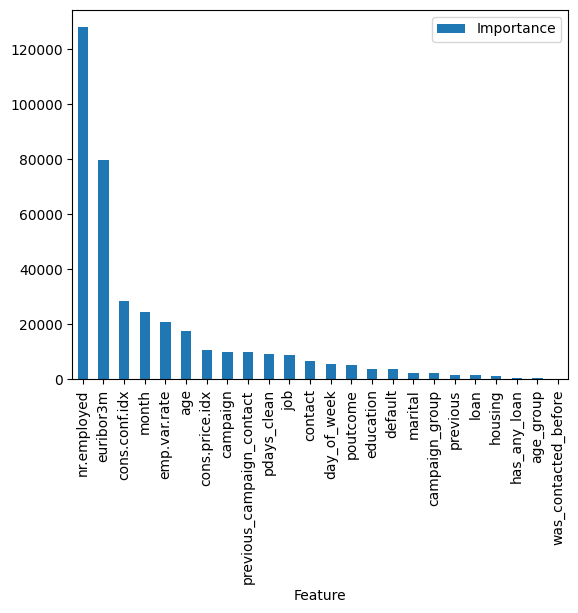

In [110]:
feature_importance_df.set_index('Feature').plot.bar();

The highest feature importance was assigned to `nr.employed`, `euribor3m`, `cons.conf.idx`, `month`, `emp.var.rate`, `age`, `cons.price.idx`, and `campaign`.

This distribution is partly logical, as the model relies on both macroeconomic factors and campaign-related behavioral characteristics.

At the same time, this approach does not indicate the direction of feature impact and may be biased in the presence of correlated variables. Therefore, for deeper interpretation, SHAP analysis will be used.

SHAP evaluates the direct contribution of each feature to the model’s prediction.

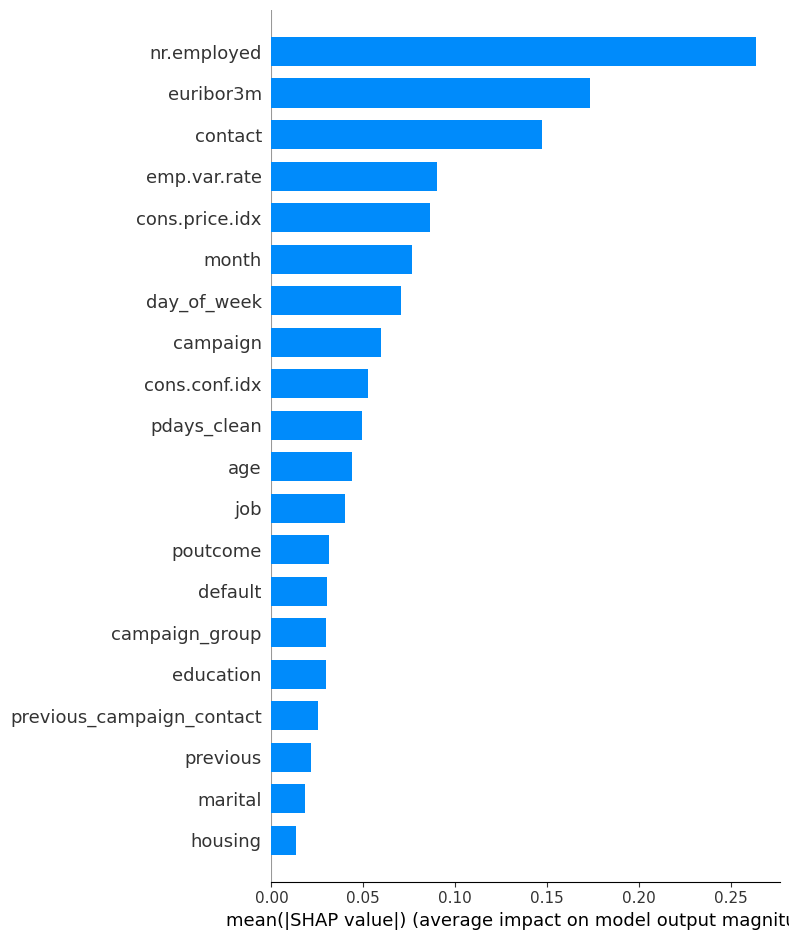

In [111]:
shap_value = shap.TreeExplainer(search.best_estimator_).shap_values(X_test_lgb)
shap.summary_plot(shap_value, X_test_lgb, plot_type="bar");

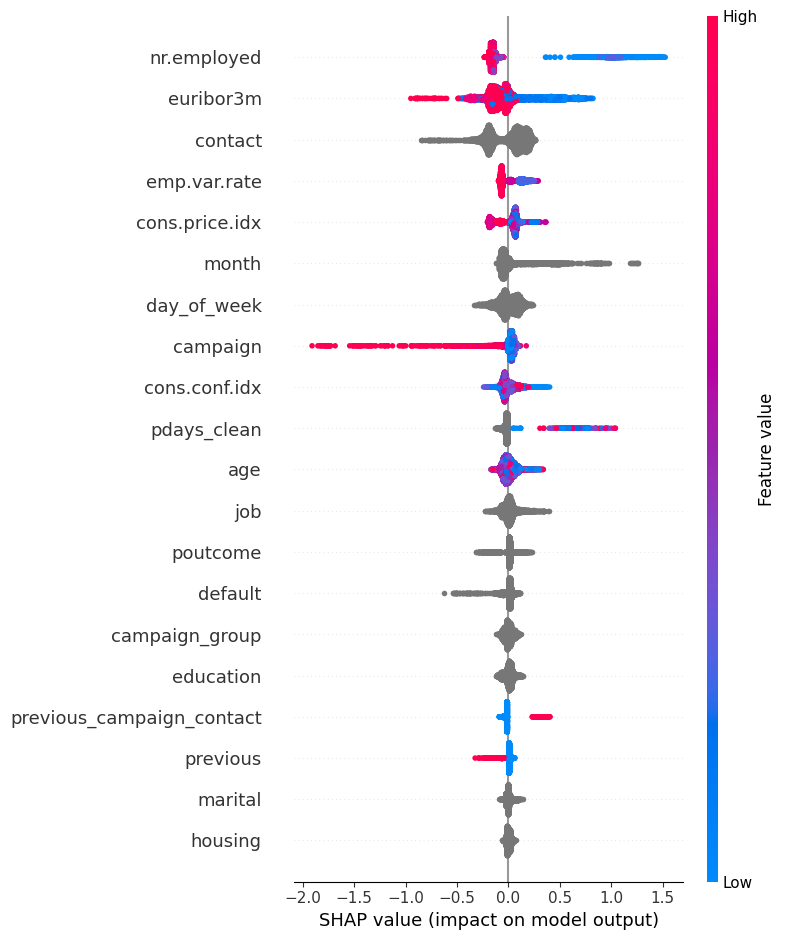

In [112]:
shap.summary_plot(shap_value, X_test_lgb);

### Macroeconomic Indicators (`nr.employed`, `euribor3m`, `emp.var.rate`)
These variables reflect the overall state of the economy:

- interest rates (`euribor3m`)  
- employment level (`nr.employed`)  
- economic fluctuations (`emp.var.rate`)  

Lower values of these indicators are associated with a higher probability of a positive prediction. Most likely, the model captures a general macroeconomic regime rather than the individual effect of each variable, since these features are highly correlated.

---

### Contact Channel (`contact`)
For the `contact` feature, EDA showed a higher probability of a positive outcome when the contact was made via `cellular` rather than `telephone`. This pattern is also confirmed by the SHAP analysis. This is logical, as mobile communication is likely a more effective and up-to-date channel.

---

### Contact Timing (`month`, `day_of_week`)
Although the model identifies `month` as an important feature, a deeper analysis suggests that this may be driven more by marketing campaign strategy than by actual client behavior.

Specifically:
- the distribution of contacts across months is uneven in the EDA (e.g., a large number of contacts in May)  
- this may influence the model due to data imbalance rather than true changes in conversion rates  

As for `day_of_week`, its impact appears minimal, since the target distribution is relatively uniform across different weekdays.

Thus, the importance of time-related features should be interpreted with caution, as they may reflect data collection patterns rather than causal relationships.

---

### Socio-Demographic Characteristics (`age`, `job`)
These features have a moderate impact. Their interpretation is less straightforward, but they may partially reflect differences in income, financial behavior, and client availability for marketing campaigns.

### Error Analysis

In [113]:
df_errors = X_test_lgb.copy()
df_errors["y_true"] = y_test.values
df_errors["y_pred"] = y_pred_search_test
df_errors["y_proba"] = y_proba_search_test

In [114]:
fp = df_errors[(df_errors["y_true"] == 0) & (df_errors["y_pred"] == 1)]
fn = df_errors[(df_errors["y_true"] == 1) & (df_errors["y_pred"] == 0)]

In [115]:
df_errors.groupby("y_true").mean(numeric_only=True)

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,previous_campaign_contact,pdays_clean,has_any_loan,y_pred,y_proba
y_true,,,,,,,,,,,,,,
0,39.869083,2.702462,0.131053,0.256389,93.602409,-40.520178,3.824220,5176.623912,0.113817,0.013133,6.479167,0.587551,0.119562,0.338473
1,40.961207,2.061422,0.453664,-1.275647,93.339559,-39.908836,2.073832,5093.800862,0.308190,0.187500,5.672414,0.619612,0.639009,0.643190


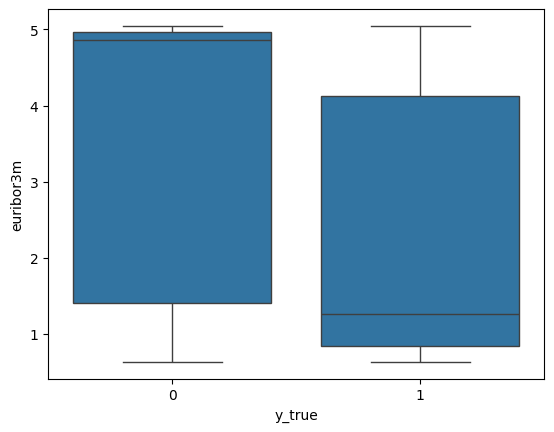

In [116]:
sns.boxplot(data=df_errors, x="y_true", y="euribor3m");

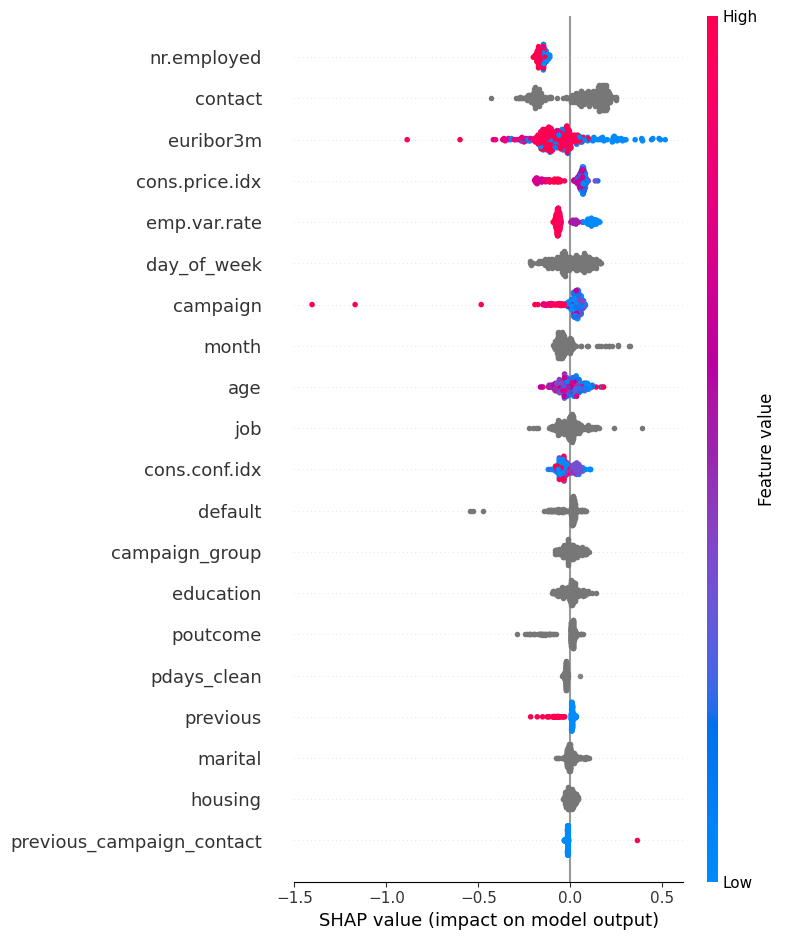

In [117]:
X_fn = fn[X_test_lgb.columns]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_fn)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_fn)

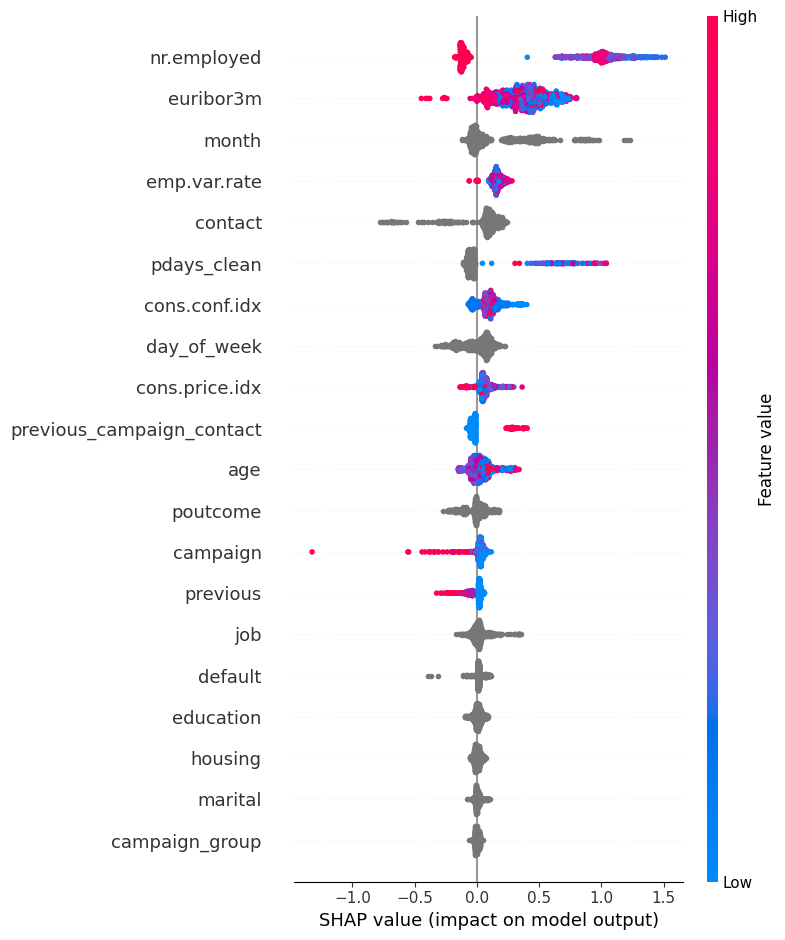

In [118]:
X_fp = fp[X_test_lgb.columns]
shap_values = explainer.shap_values(X_fp)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_fp)

Error analysis shows that the model struggles in situations where features provide conflicting signals. It tends to overemphasize macroeconomic factors and underestimate client behavioral characteristics, leading to both missed potential clients (False Negatives) and false positive predictions (False Positives).

- the model overestimates macroeconomic variables (`nr.employed`, `euribor3m`) → leads to False Positives  
- the model underestimates behavioral factors (`contact`) → leads to False Negatives  
- the model penalizes `campaign` too strongly → misses good clients (False Negatives)  
- the `month` feature introduces bias (campaign effect rather than client behavior)  
- there are cases with conflicting signals where the model “chooses the wrong side”  

To improve the model performance:

First, it is advisable to optimize the classification threshold, as the default value of 0.5 may lead to an increased number of False Negatives. Lowering the threshold can improve the model’s ability to identify potential clients.

Second, the feature engineering stage should be improved. In particular, the model may not be effectively utilizing information about the contact channel (`contact`), so it is worth considering creating additional features or interactions that better capture the impact of mobile contact (`cellular`) on the outcome.

Third, the analysis showed that the `campaign` feature has an excessively strong negative impact on predictions. Therefore, it would be reasonable to transform this variable (e.g., using logarithmic transformation or binning) to reduce its disproportionate influence on the model.

In addition, time-related features (`month`, `day_of_week`) may introduce noise and reflect marketing campaign patterns rather than actual client behavior. Thus, it is advisable to consider removing or transforming them before training the model.

Overall, model improvement can be achieved through threshold optimization, enhanced feature engineering, and reducing the impact of bias-inducing factors.